In [2]:
import numpy as np
from openxai.dataloader import ReturnLoaders
from openxai.model import LoadModel
from goodpoints import compress
import pandas as pd
import shap
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
np.seterr(all="warn")

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

<Figure size 1000x600 with 0 Axes>

In [3]:
_, loader_test = ReturnLoaders(data_name="compas", download=False, batch_size=64)
X_test = loader_test.dataset.data

model = LoadModel(data_name="compas", ml_model="ann", pretrained=True)
model.eval()

/Users/milannapahasian_user_account/Documents/CTE_thesis/OpenXAI-main/openxai/model.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path+m

ArtificialNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=2, bias=True)
  )
)

In [4]:
n = X_test.shape[0]
d = X_test.shape[1]
sigma = np.sqrt(2 * d)

In [5]:
masker_gt = shap.maskers.Independent(X_test, max_samples=X_test.shape[0])
explainer_gt = shap.PermutationExplainer(lambda x: model.predict_proba(x)[:, 1], masker_gt, seed=0)
shap_gt = explainer_gt(X_test)

PermutationExplainer explainer: 1236it [07:18,  2.76it/s]                          


In [6]:
def metric_mae(x, y):
    return np.mean(np.abs(x-y))

ranges might seem strange but my kernel dies otherwise

In [7]:
num_bins_list = []
mae_values_cte = [] 
mae_values_iid = []
len_cte = []
iid_cte_improvement = []
np.random.seed(0)

for i in range(16,65):
    id_cte = compress.compresspp_kt(X_test, kernel_type=b"gaussian", k_params=np.array([sigma**2]), num_bins=i, seed=0)
    X_cte = X_test[id_cte]
    masker_cte = shap.maskers.Independent(X_cte, max_samples=X_cte.shape[0])
    explainer_cte = shap.PermutationExplainer(lambda x: model.predict_proba(x)[:, 1], masker_cte, seed=0)
    shap_cte = explainer_cte(X_test)

    id_iid = np.random.choice(n, size=len(id_cte))
    X_iid = X_test[id_iid]
    masker_iid = shap.maskers.Independent(X_iid, max_samples=X_iid.shape[0])
    explainer_iid = shap.PermutationExplainer(lambda x: model.predict_proba(x)[:, 1], masker_iid, seed=0)
    shap_iid = explainer_iid(X_test)

    num_bins_list.append(i)
    mae_values_cte.append(metric_mae(shap_gt.values, shap_cte.values))
    mae_values_iid.append(metric_mae(shap_gt.values, shap_iid.values))  
    len_cte.append(len(id_cte))
    iid_cte_improvement.append(100*(metric_mae(shap_gt.values, shap_iid.values) - metric_mae(shap_gt.values, shap_cte.values)) / metric_mae(shap_gt.values, shap_iid.values))


PermutationExplainer explainer: 1236it [00:50, 19.86it/s]                          
PermutationExplainer explainer: 1236it [00:38, 23.82it/s]                          
PermutationExplainer explainer: 1236it [00:29, 26.66it/s]                          
PermutationExplainer explainer: 1236it [00:30, 26.77it/s]                          
PermutationExplainer explainer: 1236it [00:29, 27.61it/s]                          
PermutationExplainer explainer: 1236it [00:29, 27.46it/s]                          
PermutationExplainer explainer: 1236it [00:29, 27.43it/s]                          
PermutationExplainer explainer: 1236it [00:30, 27.26it/s]                          
PermutationExplainer explainer: 1236it [00:30, 26.86it/s]                          
PermutationExplainer explainer: 1236it [00:30, 27.06it/s]                          
PermutationExplainer explainer: 1236it [00:30, 26.84it/s]                          
PermutationExplainer explainer: 1236it [00:29, 27.64it/s]                   

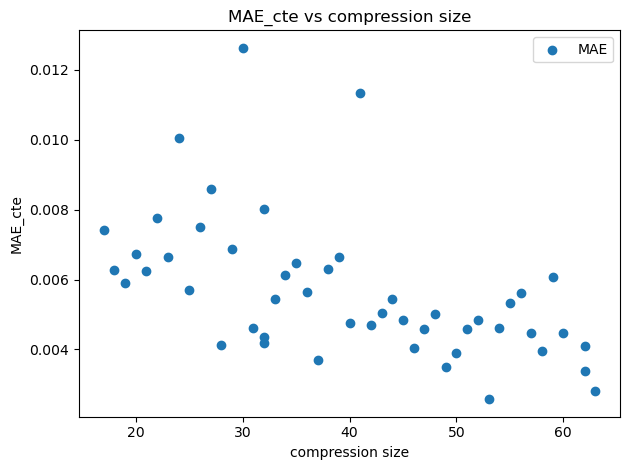

In [10]:

plt.scatter(len_cte, mae_values_cte, label="MAE")
plt.xlabel("compression size")
plt.ylabel("MAE_cte")
plt.title("MAE_cte vs compression size")
plt.legend()

plt.tight_layout()
plt.show()

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_4962/1135178738.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


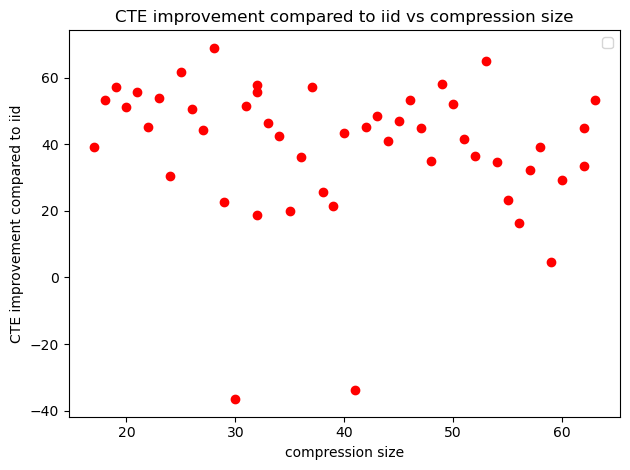

In [13]:
plt.scatter(len_cte, iid_cte_improvement, color="red")
plt.xlabel("compression size")
plt.ylabel("CTE improvement compared to iid")
plt.title("CTE improvement compared to iid vs compression size")
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
df = pd.DataFrame({
    "num_bins": num_bins_list,
    "mae_values_cte": mae_values_cte,
    "mae_values_iid": mae_values_iid,
    "len_cte": len_cte,
    "iid_cte_improvement": iid_cte_improvement
})

df.to_csv("compression_results_num-bins_16-64_range.csv", index=False)

PermutationExplainer explainer: 1236it [00:50, 19.86it/s]                          
PermutationExplainer explainer: 1236it [00:38, 23.82it/s]                          
PermutationExplainer explainer: 1236it [00:29, 26.66it/s]                          
PermutationExplainer explainer: 1236it [00:30, 26.77it/s]                          
PermutationExplainer explainer: 1236it [00:29, 27.61it/s]                          
PermutationExplainer explainer: 1236it [00:29, 27.46it/s]                          
PermutationExplainer explainer: 1236it [00:29, 27.43it/s]                          
PermutationExplainer explainer: 1236it [00:30, 27.26it/s]                          
PermutationExplainer explainer: 1236it [00:30, 26.86it/s]                          
PermutationExplainer explainer: 1236it [00:30, 27.06it/s]                          
PermutationExplainer explainer: 1236it [00:30, 26.84it/s]                          
PermutationExplainer explainer: 1236it [00:29, 27.64it/s]                          
PermutationExplainer explainer: 1236it [00:29, 27.22it/s]                          
PermutationExplainer explainer: 1236it [00:30, 27.55it/s]                          
PermutationExplainer explainer: 1236it [00:30, 26.99it/s]                          
PermutationExplainer explainer: 1236it [00:31, 26.44it/s]                          
PermutationExplainer explainer: 1236it [00:32, 26.19it/s]                          
PermutationExplainer explainer: 1236it [00:32, 26.75it/s]                          
PermutationExplainer explainer: 1236it [00:32, 26.21it/s]                          
PermutationExplainer explainer: 1236it [00:31, 26.40it/s]                          
PermutationExplainer explainer: 1236it [00:32, 25.88it/s]                          
PermutationExplainer explainer: 1236it [00:32, 26.11it/s]                          
PermutationExplainer explainer: 1236it [00:35, 24.77it/s]                          
PermutationExplainer explainer: 1236it [00:33, 25.78it/s]                          
PermutationExplainer explainer: 1236it [00:34, 25.26it/s]                          
PermutationExplainer explainer: 1236it [00:33, 25.54it/s]                          
PermutationExplainer explainer: 1236it [00:34, 25.50it/s]                          
PermutationExplainer explainer: 1236it [00:34, 25.24it/s]                          
PermutationExplainer explainer: 1236it [00:34, 25.24it/s]                          
PermutationExplainer explainer: 1236it [00:34, 24.97it/s]                          
PermutationExplainer explainer: 1236it [00:35, 25.23it/s]                          
PermutationExplainer explainer: 1236it [00:36, 24.92it/s]                          
PermutationExplainer explainer: 1236it [00:35, 24.76it/s]                          
PermutationExplainer explainer: 1236it [00:35, 24.62it/s]                          
PermutationExplainer explainer: 1236it [00:36, 24.21it/s]                          
PermutationExplainer explainer: 1236it [00:35, 24.73it/s]                          
PermutationExplainer explainer: 1236it [00:35, 24.71it/s]                          
PermutationExplainer explainer: 1236it [00:39, 22.31it/s]                          
PermutationExplainer explainer: 1236it [00:31, 26.47it/s]                          
PermutationExplainer explainer: 1236it [00:33, 25.25it/s]                          
PermutationExplainer explainer: 1236it [00:32, 24.71it/s]                          
PermutationExplainer explainer: 1236it [00:39, 23.23it/s]                          
PermutationExplainer explainer: 1236it [00:39, 24.74it/s]                          
PermutationExplainer explainer: 1236it [00:33, 25.57it/s]                          
PermutationExplainer explainer: 1236it [00:36, 25.73it/s]                          
PermutationExplainer explainer: 1236it [00:33, 25.40it/s]                          
PermutationExplainer explainer: 1236it [00:35, 24.43it/s]                          
PermutationExplainer explainer: 1236it [00:34, 24.73it/s]                          
PermutationExplainer explainer: 1236it [00:37, 23.55it/s]                          
PermutationExplainer explainer: 1236it [00:41, 21.38it/s]                          
PermutationExplainer explainer: 1236it [00:40, 22.96it/s]                          
PermutationExplainer explainer: 1236it [00:39, 22.85it/s]                          
PermutationExplainer explainer: 1236it [00:40, 22.34it/s]                          
PermutationExplainer explainer: 1236it [00:41, 21.99it/s]                          
PermutationExplainer explainer: 1236it [00:43, 20.92it/s]                          
PermutationExplainer explainer: 1236it [00:41, 22.48it/s]                          
PermutationExplainer explainer: 1236it [00:39, 22.98it/s]                          
PermutationExplainer explainer: 1236it [00:40, 22.74it/s]                          
PermutationExplainer explainer: 1236it [00:40, 22.85it/s]                          
PermutationExplainer explainer: 1236it [00:41, 22.84it/s]                          
PermutationExplainer explainer: 1236it [00:40, 23.09it/s]                          
PermutationExplainer explainer: 1236it [00:39, 22.87it/s]                          
PermutationExplainer explainer: 1236it [00:42, 21.94it/s]                          
PermutationExplainer explainer: 1236it [00:40, 22.69it/s]                          
PermutationExplainer explainer: 1236it [00:41, 22.60it/s]                          
PermutationExplainer explainer: 1236it [00:40, 22.90it/s]                          
PermutationExplainer explainer: 1236it [00:40, 22.97it/s]                          
PermutationExplainer explainer: 1236it [00:40, 22.54it/s]                          
PermutationExplainer explainer: 1236it [00:41, 22.33it/s]                          
PermutationExplainer explainer: 1236it [00:41, 22.33it/s]                          
PermutationExplainer explainer: 1236it [00:41, 22.23it/s]                          
PermutationExplainer explainer: 1236it [00:43, 21.09it/s]                          
PermutationExplainer explainer: 1236it [00:46, 19.77it/s]                          
PermutationExplainer explainer: 1236it [00:42, 22.46it/s]                          
PermutationExplainer explainer: 1236it [00:42, 21.68it/s]                          
PermutationExplainer explainer: 1236it [00:41, 22.10it/s]                          
PermutationExplainer explainer: 1236it [00:42, 21.87it/s]                          
PermutationExplainer explainer: 1236it [00:41, 22.24it/s]                          
PermutationExplainer explainer: 1236it [00:42, 21.77it/s]                          
PermutationExplainer explainer: 1236it [00:42, 22.10it/s]                          
PermutationExplainer explainer: 1236it [00:43, 21.58it/s]                          
PermutationExplainer explainer: 1236it [00:42, 21.96it/s]                          
PermutationExplainer explainer: 1236it [00:43, 21.54it/s]                          
PermutationExplainer explainer: 1236it [00:43, 21.36it/s]                          
PermutationExplainer explainer: 1236it [00:44, 21.21it/s]                          
PermutationExplainer explainer: 1236it [00:44, 20.99it/s]                          
PermutationExplainer explainer: 1236it [00:45, 20.82it/s]                          
PermutationExplainer explainer: 1236it [00:45, 20.88it/s]                          
PermutationExplainer explainer: 1236it [00:45, 20.93it/s]                          
PermutationExplainer explainer: 1236it [00:46, 20.53it/s]                          
PermutationExplainer explainer: 1236it [00:47, 20.35it/s]                          
PermutationExplainer explainer: 1236it [00:46, 20.63it/s]                          
PermutationExplainer explainer: 1236it [00:46, 20.37it/s]                          
PermutationExplainer explainer: 1236it [00:49, 19.39it/s]                          
PermutationExplainer explainer: 1236it [00:45, 20.88it/s]                          
PermutationExplainer explainer: 1236it [00:44, 21.23it/s]                          
PermutationExplainer explainer: 1236it [00:30, 26.91it/s]                          
PermutationExplainer explainer: 1236it [00:30, 26.62it/s]                          


/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_4962/3566152008.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


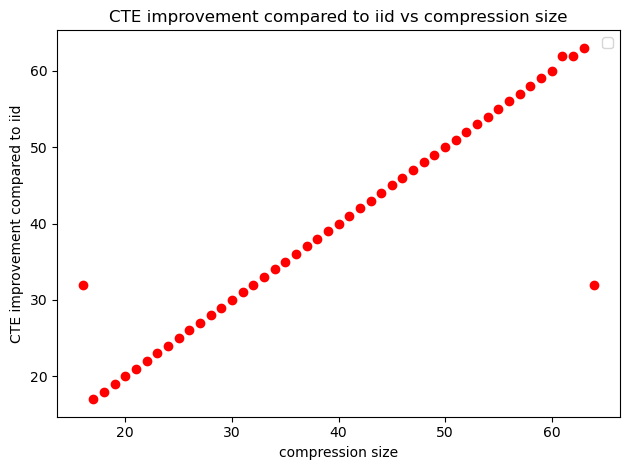

In [15]:
plt.scatter(num_bins_list, len_cte, color="red")
plt.xlabel("compression size")
plt.ylabel("CTE improvement compared to iid")
plt.title("CTE improvement compared to iid vs compression size")
plt.legend()

plt.tight_layout()
plt.show()